・帰無仮説1：温度条件は合成樹脂の製造量に変化を与えない

・対立仮説1：温度条件は合成樹脂の製造量に変化を与える

・帰無仮説2：時間条件は合成樹脂の製造量に変化を与えない

・対立仮説2：時間条件は合成樹脂の製造量に変化を与える

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

sns.set_theme()

In [2]:
data=pd.read_csv("reagents_data.csv")

In [3]:
data.head()

,Temp,Time,Volume
0,100,10,21.624345
1,100,10,19.388244
2,100,10,19.471828
3,100,10,18.927031
4,100,10,20.865408


In [4]:
data.describe()

,Temp,Time,Volume
count,40.000000,40.000000,40.000000
mean,150.000000,20.000000,21.064619
std,50.636968,10.127394,1.525618
min,100.000000,10.000000,17.698461
25%,100.000000,10.000000,19.966199
50%,150.000000,20.000000,21.195695
75%,200.000000,30.000000,21.767238
max,200.000000,30.000000,25.577257


In [5]:
data.groupby("Temp").describe()

Time                                                Volume             \
     count  mean        std   min   25%   50%   75%   max  count       mean   
Temp                                                                          
100   20.0  20.0  10.259784  10.0  10.0  20.0  30.0  30.0   20.0  20.810951   
200   20.0  20.0  10.259784  10.0  10.0  20.0  30.0  30.0   20.0  21.318288   

                                                                       
           std        min        25%        50%        75%        max  
Temp                                                                   
100   1.787412  17.698461  19.450932  20.955486  21.767238  25.577257  
200   1.203001  19.415423  20.452503  21.416101  21.824654  23.639291

In [6]:
data.groupby("Time").describe()

Temp                                                      Volume  \
     count   mean        std    min    25%    50%    75%    max  count   
Time                                                                     
10    20.0  150.0  51.298918  100.0  100.0  150.0  200.0  200.0   20.0   
30    20.0  150.0  51.298918  100.0  100.0  150.0  200.0  200.0   20.0   

                                                                       \
           mean       std        min        25%        50%        75%   
Time                                                                    
10    20.320478  1.114516  17.698461  19.457727  20.335666  21.374175   
30    21.808761  1.539349  18.273015  21.087072  21.761367  22.765008   

                 
            max  
Time             
10    21.744812  
30    25.577257

<Axes: xlabel='Temp', ylabel='Volume'>

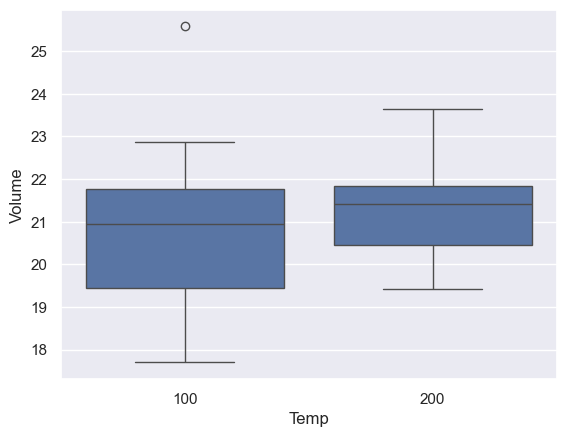

In [7]:
#温度条件と製造量のひげ図
sns.boxplot(x="Temp",y="Volume",data=data)

<Axes: xlabel='Temp', ylabel='Volume'>

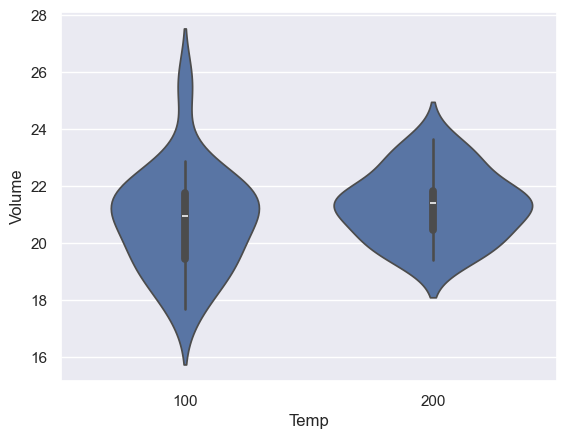

In [8]:
#温度条件と製造量のバイオリンプロット
sns.violinplot(x="Temp",y="Volume",data=data)

<Axes: xlabel='Time', ylabel='Volume'>

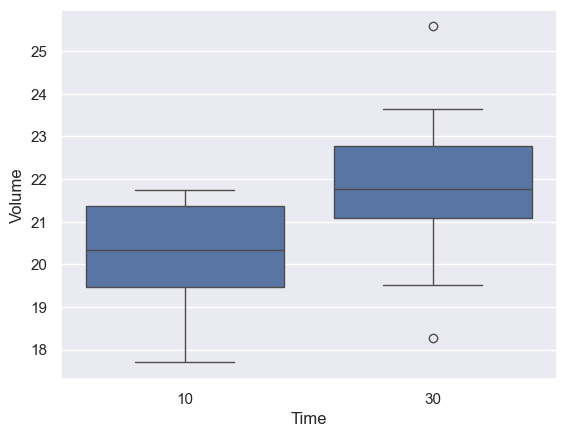

In [9]:
#反応時間と製造量の箱ひげ図
sns.boxplot(x="Time",y="Volume",data=data)

<Axes: xlabel='Time', ylabel='Volume'>

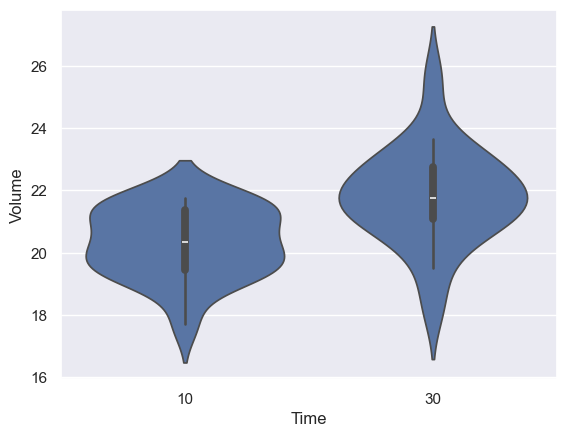

In [10]:
#反応時間と製造量のバイオリンプロット
sns.violinplot(x="Time",y="Volume",data=data)

In [11]:
#全データの製造量の平均値
me_all=np.mean(data["Volume"])
me_all

np.float64(21.064619498696487)

In [12]:
#温度条件ごとの製造量の平均値
me_Temp100=np.mean(data.query("Temp==100")["Volume"])
me_Temp200=np.mean(data.query("Temp==200")["Volume"])
print("Temp 100:",me_Temp100)
print("Temp 200:",me_Temp200)

Temp 100: 20.81095130951942
Temp 200: 21.318287687873553


In [13]:
#反応時間ごとの製造量の平均値
me_Time10=np.mean(data.query("Time==10")["Volume"])
me_Time30=np.mean(data.query("Time==30")["Volume"])
print("Time 10:",me_Time10)
print("Time 30:",me_Time30)

Time 10: 20.32047783804376
Time 30: 21.80876115934921


In [14]:
#全体の平方和
squares_all2=np.sum((data["Volume"]-me_all)**2)
squares_all2

np.float64(90.77291728168143)

In [15]:
#温度条件の平方和
temp_means_list=[me_Temp100]*data.query("Temp==100").shape[0]+[me_Temp200]*data.query("Temp==200").shape[0]
temp_means_expanded=np.array(temp_means_list)
squares_temp=np.sum((temp_means_expanded-me_all)**2)
squares_temp

np.float64(2.5739020080148745)

In [16]:
#反応時間の平方和
time_means_list=[me_Time10]*data.query("Time==10").shape[0]+[me_Time30]*data.query("Time==30").shape[0]
time_means_expanded=np.array(time_means_list)
squares_time=np.sum((time_means_expanded-me_all)**2)
squares_time

np.float64(22.14987244475978)

In [17]:
#誤差の平方和
squares_resid2=squares_all2-squares_temp-squares_time
squares_resid2

np.float64(66.04914282890678)

In [18]:
#全体の自由度
df_all=len(data)-1
df_all

39

In [19]:
#温度条件の自由度
df_temp=len(set(data["Temp"]))-1
df_temp

1

In [20]:
#反応時間の自由度
df_time=len(set(data["Time"]))-1
df_time

1

In [21]:
#誤差の自由度
df_resid=df_all-df_temp-df_time
df_resid

37

In [22]:
#温度条件の分散
variance_temp=squares_temp/df_temp
variance_temp

np.float64(2.5739020080148745)

In [23]:
#反応時間の分散
variance_time=squares_time/df_time
variance_time

np.float64(22.14987244475978)

In [24]:
#誤差の分散
variance_resid2=squares_resid2/df_resid
variance_resid2

np.float64(1.785111968348832)

In [25]:
#温度条件のF比
f_ratio_temp=variance_temp/variance_resid2
f_ratio_temp

np.float64(1.4418714644525332)

In [26]:
#反応時間のF比
f_ratio_time=variance_time/variance_resid2
f_ratio_time

np.float64(12.408113797616663)

In [ ]:
#誤差のF比は無し

In [27]:
#温度条件のp値
1-sp.stats.f.cdf(x=f_ratio_temp,dfn=df_temp,dfd=df_resid)

np.float64(0.23746784737213245)

In [28]:
#反応時間のF比
1-sp.stats.f.cdf(x=f_ratio_time,dfn=df_time,dfd=df_resid)

np.float64(0.0011555176940120093)

In [ ]:
#誤差のp値は無し

In [ ]:
#二元分散分析を実行
anova_model=smf.ols("Volume~Temp+Time",data=data).fit()
sm.stats.anova_lm(anova_model,typ=2)

,sum_sq,df,F,PR(>F)
Temp,2.573902,1.0,1.441871,0.237468
Time,22.149872,1.0,12.408114,0.001156
Residual,66.049143,37.0,NaN,NaN


温度条件についてはp値が0.05を上回ったため帰無仮説1を棄却することはできない。

よって、「温度条件によって合成樹脂の製造量に差があるとは言い切れない」と判断する。

一方で、反応時間についてはp値が0.05を下回ったため帰無仮説2を棄却することができる。

よって、「時間条件によって合成樹脂の製造量に有意差がある」と判断できる。